### Cluster 4 (658 companies, 115 bankrupt)
### Strategy: Weighted Stacking

In [13]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
CLUSTER_ID = 4
INPUT_FILE = f"cluster_{CLUSTER_ID}.csv"
FEATURE_FILE = "top_features_for_clustering.joblib"
OUTPUT_MODEL = f"cluster{CLUSTER_ID}_stacking.joblib"
RANDOM_STATE = 0

# Data Loading
print(f"Loading data for Cluster {CLUSTER_ID}...")
df = pd.read_csv(INPUT_FILE)
print(f"Shape: {df.shape}")
print(f"Class Distribution:\n{df['Bankrupt?'].value_counts()}")

features_to_use = joblib.load(FEATURE_FILE)
print(f"Loaded {len(features_to_use)} features.")
X = df[features_to_use]
y = df["Bankrupt?"]

Loading data for Cluster 4...
Shape: (658, 98)
Class Distribution:
Bankrupt?
0    543
1    115
Name: count, dtype: int64
Loaded 40 features.


In [15]:
# Define Base Models
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=RANDOM_STATE
)

knn = KNeighborsClassifier(n_neighbors=3)

estimators = [
    ('rf', rf),
    ('gb', gb),
    ('knn', knn)
]

In [16]:
# Define & Train Stacking Model (PCA N=5)

stacking_layer = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced'),
    cv=5, 
    n_jobs=-1
)

clf_stack = make_pipeline(
    StandardScaler(),
    PCA(n_components=5, random_state=RANDOM_STATE),
    stacking_layer
)

clf_stack.fit(X, y)
print("Training Complete.")

Training Complete.


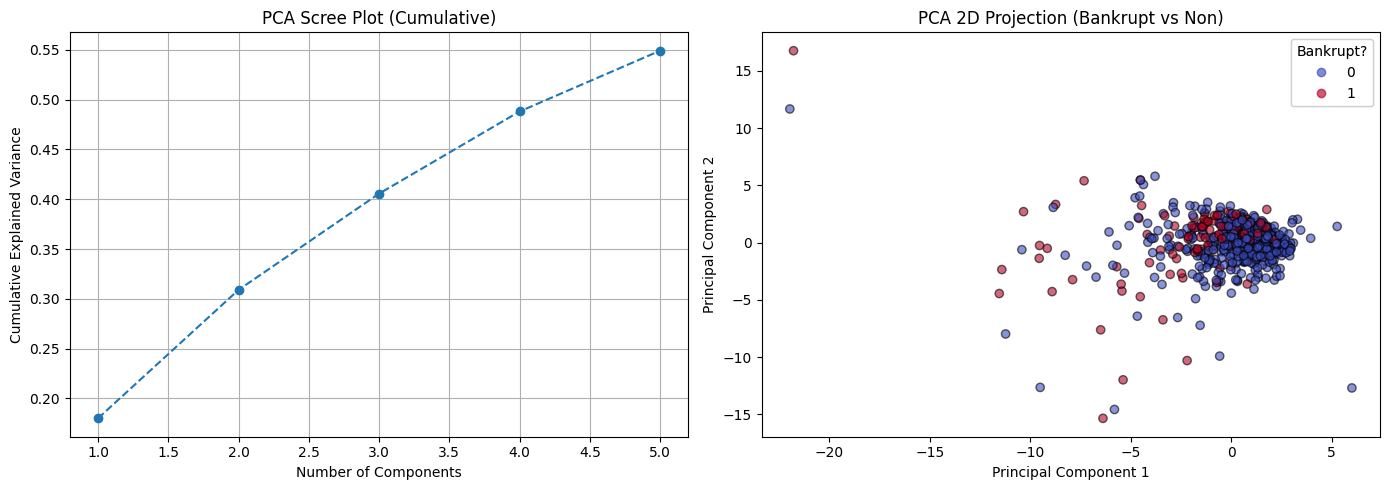

In [17]:
# Visual 3: PCA Analysis
# Extract PCA from the pipeline (step name 'pca' is default for PCA())
pca_model = clf_stack.named_steps['pca']
explained_variance = np.cumsum(pca_model.explained_variance_ratio_)
X_pca = clf_stack[:-1].transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree Plot
axes[0].plot(range(1, 6), explained_variance, marker='o', linestyle='--')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Scree Plot (Cumulative)')
axes[0].grid(True)

# 2D Scatter Projection (PC1 vs PC2)
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].set_title('PCA 2D Projection (Bankrupt vs Non)')
legend1 = axes[1].legend(*scatter.legend_elements(), title="Bankrupt?")
axes[1].add_artist(legend1)

plt.tight_layout()
plt.show()

RESULTS FOR TABLE 3 (Cluster 4)

Base Model Performance (on full train set):
Base: rf
Confusion Matrix: [[543, 0], [0, 115]]
Eq(1) Accuracy: 1.0000
Base: gb
Confusion Matrix: [[542, 1], [30, 85]]
Eq(1) Accuracy: 0.7391
Base: knn
Confusion Matrix: [[523, 20], [52, 63]]
Eq(1) Accuracy: 0.5478

Stacking Model Performance (Final):
STACKING MODEL
Confusion Matrix: [[511, 32], [0, 115]]
Eq(1) Accuracy: 1.0000


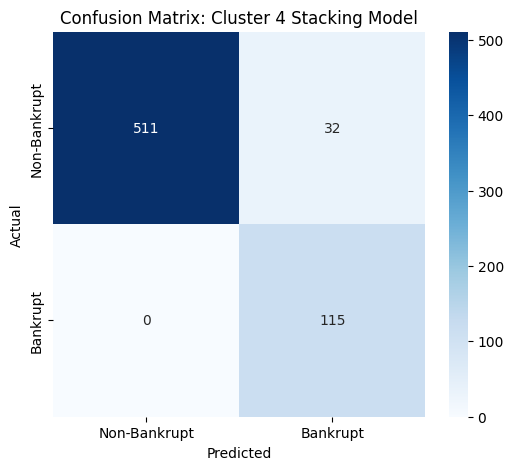

Stats for Table 3 -> TT: 115, TF: 0, N_features: 5


In [18]:
# Evaluation & Compliance
def get_metrics(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    FF, FT, TF, TT = cm.ravel()
    
    acc_eq1 = TT / (TF + TT) if (TF + TT) > 0 else 0
    
    print(f"{name}")
    print(f"Confusion Matrix: [[{FF}, {FT}], [{TF}, {TT}]]")
    print(f"Eq(1) Accuracy: {acc_eq1:.4f}")
    return FF, FT, TF, TT, acc_eq1

print(f"RESULTS FOR TABLE 3 (Cluster {CLUSTER_ID})")

# Recalculate transform for evaluation loop visibility if needed, though we have X_pca
X_transformed = clf_stack[:-1].transform(X)
stacking_model = clf_stack[-1]

# Base Model Performance
print("\nBase Model Performance (on full train set):")
for name, est in stacking_model.named_estimators_.items():
    y_pred_base = est.predict(X_transformed)
    get_metrics(y, y_pred_base, f"Base: {name}")

# Stacking Model Performance
print("\nStacking Model Performance (Final):")
y_pred_stack = clf_stack.predict(X)
FF, FT, TF, TT, acc = get_metrics(y, y_pred_stack, "STACKING MODEL")

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y, y_pred_stack)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Bankrupt', 'Bankrupt'], 
            yticklabels=['Non-Bankrupt', 'Bankrupt'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix: Cluster {CLUSTER_ID} Stacking Model')
plt.show()


model_package = {
    "cluster_id": CLUSTER_ID,
    "features": features_to_use,
    "model": clf_stack,
    "stats": {"TT": TT, "TF": TF, "N_features": 5}
}

joblib.dump(model_package, OUTPUT_MODEL)
print(f"Stats for Table 3 -> TT: {TT}, TF: {TF}, N_features: 5")